<a href="https://colab.research.google.com/github/vunnampragathi/PhDAI-731/blob/main/assignment_3_supply_chain_optimization_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Supply Chain Optimization

This Google Colab notebook performs the assignment step by step:

1. Collect real population data from the U.S. Census Bureau API.
2. Create a transparent logistics planning dataset informed by BTS freight concepts.
3. Build transportation distance, delivery-time, and cost matrices.
4. Solve a Linear Programming transportation model.
5. Solve a Mixed-Integer Linear Programming warehouse-location model.
6. Run a heuristic Differential Evolution model.
7. Run a gradient-based SLSQP allocation model.
8. Validate all constraints.
9. Conduct sensitivity analysis.
10. Generate tables, charts, and CSV files.

**Important:** Census population figures are real public data. Warehouse capacities, fixed costs, demand conversion, and company-specific freight rates are synthetic because the assignment links do not provide a single company-level warehouse dataset.


## Step 1 — Install packages

In [ ]:
!pip -q install --upgrade scipy networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 22.9 MB/s eta 0:00:00


## Step 2 — Import libraries

In [ ]:
import math, time, warnings, shutil
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import requests
import scipy
from scipy.optimize import Bounds, LinearConstraint, differential_evolution, linprog, milp, minimize
warnings.filterwarnings("ignore")
print("SciPy:", scipy.__version__)
print("Setup complete.")

SciPy: 1.18.0
Setup complete.


## Step 3 — Define warehouse and customer locations

In [ ]:
WAREHOUSES = ["Dallas", "Chicago", "Atlanta", "Los Angeles", "New York"]
CUSTOMERS = ["Seattle","San Francisco","Denver","Phoenix","Dallas","Chicago","Atlanta","Miami","Washington","New York"]

COORDINATES = {
    "Dallas": (32.7767, -96.7970), "Chicago": (41.8781, -87.6298),
    "Atlanta": (33.7490, -84.3880), "Los Angeles": (34.0522, -118.2437),
    "New York": (40.7128, -74.0060), "Seattle": (47.6062, -122.3321),
    "San Francisco": (37.7749, -122.4194), "Denver": (39.7392, -104.9903),
    "Phoenix": (33.4484, -112.0740), "Miami": (25.7617, -80.1918),
    "Washington": (38.9072, -77.0369)
}

CITY_LOOKUP = {
    "Seattle": {"state": "53", "match": "Seattle city"},
    "San Francisco": {"state": "06", "match": "San Francisco city"},
    "Denver": {"state": "08", "match": "Denver city"},
    "Phoenix": {"state": "04", "match": "Phoenix city"},
    "Dallas": {"state": "48", "match": "Dallas city"},
    "Chicago": {"state": "17", "match": "Chicago city"},
    "Atlanta": {"state": "13", "match": "Atlanta city"},
    "Miami": {"state": "12", "match": "Miami city"},
    "Washington": {"state": "11", "match": "Washington city"},
    "New York": {"state": "36", "match": "New York city"},
}
print(WAREHOUSES)
print(CUSTOMERS)

['Dallas', 'Chicago', 'Atlanta', 'Los Angeles', 'New York']
['Seattle', 'San Francisco', 'Denver', 'Phoenix', 'Dallas', 'Chicago', 'Atlanta', 'Miami', 'Washington', 'New York']


## Step 4 — Download real Census population data

In [ ]:



CENSUS_API_KEY = "37770c8d9364dd4bc0bc086491faf309814d22af"


def get_city_population(
    city_name,
    state_fips,
    match_text,
    year=2024,
    api_key=CENSUS_API_KEY
):
    state_fips = str(state_fips).zfill(2)

    url = f"https://api.census.gov/data/{year}/acs/acs5"

    params = {
        "get": "NAME,B01003_001E",
        "for": "place:*",
        "in": f"state:{state_fips}",
        "key": api_key
    }

    response = requests.get(
        url,
        params=params,
        timeout=30
    )

    print(f"Getting data for {city_name}...")
    print("Request URL:", response.url)
    print("Status code:", response.status_code)

    response.raise_for_status()

    content_type = response.headers.get("Content-Type", "")

    if "json" not in content_type.lower():
        print("Response content type:", content_type)
        print("Response preview:")
        print(response.text[:500])

        raise RuntimeError(
            f"Census API did not return JSON for {city_name}. "
            "Check whether your API key is valid."
        )

    rows = response.json()

    if len(rows) < 2:
        raise ValueError(
            f"No Census population records were returned for {city_name}."
        )

    df = pd.DataFrame(
        rows[1:],
        columns=rows[0]
    )

    df["B01003_001E"] = pd.to_numeric(
        df["B01003_001E"],
        errors="coerce"
    )

    matched = df[
        df["NAME"]
        .fillna("")
        .str.contains(
            match_text,
            case=False,
            regex=False
        )
    ]

    if matched.empty:
        possible_matches = df[
            df["NAME"]
            .fillna("")
            .str.contains(
                city_name,
                case=False,
                regex=False
            )
        ]["NAME"].tolist()

        raise ValueError(
            f"Could not find {city_name}. "
            f"Possible matches: {possible_matches[:10]}"
        )

    row = matched.iloc[0]

    return {
        "Market": city_name,
        "Census geography": row["NAME"],
        "Population": int(row["B01003_001E"]),
        "State FIPS": state_fips,
        "Place FIPS": row["place"],
        "Census year": year
    }

In [ ]:
test_dallas = get_city_population(
    city_name="Dallas",
    state_fips=CITY_LOOKUP["Dallas"]["state"],
    match_text=CITY_LOOKUP["Dallas"]["match"],
    year=2024
)

test_dallas

Getting data for Dallas...
Request URL: https://api.census.gov/data/2024/acs/acs5?get=NAME%2CB01003_001E&for=place%3A%2A&in=state%3A48&key=37770c8d9364dd4bc0bc086491faf309814d22af
Status code: 200


{'Market': 'Dallas',
 'Census geography': 'Dallas city, Texas',
 'Population': 1307930,
 'State FIPS': '48',
 'Place FIPS': '19000',
 'Census year': 2024}

In [ ]:
population_records = []
population_errors = []

for city in CUSTOMERS:
    info = CITY_LOOKUP[city]

    try:
        result = get_city_population(
            city_name=city,
            state_fips=info["state"],
            match_text=info["match"],
            year=2024
        )

        population_records.append(result)

    except Exception as error:
        print(f"Error for {city}: {error}")

        population_errors.append({
            "City": city,
            "Error": str(error)
        })


population_df = pd.DataFrame(population_records)

display(population_df)

Getting data for Seattle...
Request URL: https://api.census.gov/data/2024/acs/acs5?get=NAME%2CB01003_001E&for=place%3A%2A&in=state%3A53&key=37770c8d9364dd4bc0bc086491faf309814d22af
Status code: 200
Getting data for San Francisco...
Request URL: https://api.census.gov/data/2024/acs/acs5?get=NAME%2CB01003_001E&for=place%3A%2A&in=state%3A06&key=37770c8d9364dd4bc0bc086491faf309814d22af
Status code: 200
Getting data for Denver...
Request URL: https://api.census.gov/data/2024/acs/acs5?get=NAME%2CB01003_001E&for=place%3A%2A&in=state%3A08&key=37770c8d9364dd4bc0bc086491faf309814d22af
Status code: 200
Getting data for Phoenix...
Request URL: https://api.census.gov/data/2024/acs/acs5?get=NAME%2CB01003_001E&for=place%3A%2A&in=state%3A04&key=37770c8d9364dd4bc0bc086491faf309814d22af
Status code: 200
Getting data for Dallas...
Request URL: https://api.census.gov/data/2024/acs/acs5?get=NAME%2CB01003_001E&for=place%3A%2A&in=state%3A48&key=37770c8d9364dd4bc0bc086491faf309814d22af
Status code: 200
Gettin

,Market,Census geography,Population,State FIPS,Place FIPS,Census year
0,Seattle,"Seattle city, Washington",754195,53,63000,2024
1,San Francisco,"San Francisco city, California",830235,06,67000,2024
2,Denver,"Denver city, Colorado",718877,08,20000,2024
3,Phoenix,"Phoenix city, Arizona",1642323,04,55000,2024
4,Dallas,"Dallas city, Texas",1307930,48,19000,2024
5,Chicago,"Chicago city, Illinois",2711226,17,14000,2024
6,Atlanta,"Atlanta city, Georgia",505268,13,04000,2024
7,Miami,"Miami city, Florida",459745,12,45000,2024
8,Washington,"Washington city, District of Columbia",681294,11,50000,2024
9,New York,"New York city, New York",8483844,36,51000,2024


### Checkpoint — verify all ten markets

In [ ]:
assert len(population_df) == 10
assert population_df["Population"].notna().all()
assert (population_df["Population"] > 0).all()
print("Population validation passed.")
print("Total population:", f"{population_df['Population'].sum():,}")

Population validation passed.
Total population: 18,094,937


## Step 5 — Convert population into annual demand

In [ ]:
DEMAND_RATE = 0.05
population_df["Annual demand units"] = ((population_df["Population"] * DEMAND_RATE / 1000).round() * 1000).astype(int)
demand_lookup = population_df.set_index("Market")["Annual demand units"]
DEMAND = np.array([demand_lookup[c] for c in CUSTOMERS], dtype=float)
customer_df = population_df[["Market","Census geography","Population","Annual demand units","Census year"]].copy()
customer_df

,Market,Census geography,Population,Annual demand units,Census year
0,Seattle,"Seattle city, Washington",754195,38000,2024
1,San Francisco,"San Francisco city, California",830235,42000,2024
2,Denver,"Denver city, Colorado",718877,36000,2024
3,Phoenix,"Phoenix city, Arizona",1642323,82000,2024
4,Dallas,"Dallas city, Texas",1307930,65000,2024
5,Chicago,"Chicago city, Illinois",2711226,136000,2024
6,Atlanta,"Atlanta city, Georgia",505268,25000,2024
7,Miami,"Miami city, Florida",459745,23000,2024
8,Washington,"Washington city, District of Columbia",681294,34000,2024
9,New York,"New York city, New York",8483844,424000,2024


## Step 6 — Define synthetic warehouse capacity and fixed costs

In [ ]:
CAPACITY = np.array([620000,600000,570000,560000,540000], dtype=float)
FIXED_COST = np.array([1350000,1550000,1250000,1750000,1900000], dtype=float)

warehouse_df = pd.DataFrame({
    "Warehouse": WAREHOUSES,
    "Annual capacity units": CAPACITY.astype(int),
    "Annual fixed cost ($)": FIXED_COST.astype(int)
})
display(warehouse_df)
print("Total demand:", f"{DEMAND.sum():,.0f}")
print("Total capacity:", f"{CAPACITY.sum():,.0f}")
assert CAPACITY.sum() >= DEMAND.sum()
print("Capacity checkpoint passed.")

,Warehouse,Annual capacity units,Annual fixed cost ($)
0,Dallas,620000,1350000
1,Chicago,600000,1550000
2,Atlanta,570000,1250000
3,Los Angeles,560000,1750000
4,New York,540000,1900000


Total demand: 905,000
Total capacity: 2,890,000
Capacity checkpoint passed.


## Step 7 — Build route distance, time, cost, and feasibility matrices

In [ ]:
def haversine_miles(a, b):
    lat1, lon1 = map(math.radians, a)
    lat2, lon2 = map(math.radians, b)
    dlat, dlon = lat2-lat1, lon2-lon1
    h = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return 2 * 3958.8 * math.asin(math.sqrt(h))

ROAD_FACTOR = 1.16
AVERAGE_SPEED_MPH = 52.0
SERVICE_TIME_HOURS = 2.0
MAX_DELIVERY_HOURS = 42.0
COST_PER_UNIT_MILE = 0.00155
REGIONAL_COST_FACTOR = np.array([0.98,1.03,0.97,1.10,1.12]).reshape(-1,1)

M, N = len(WAREHOUSES), len(CUSTOMERS)
DISTANCE = np.zeros((M,N))

for i,w in enumerate(WAREHOUSES):
    for j,c in enumerate(CUSTOMERS):
        d = haversine_miles(COORDINATES[w], COORDINATES[c])
        DISTANCE[i,j] = 20.0 if w == c else max(20.0, d * ROAD_FACTOR)

DELIVERY_TIME = DISTANCE / AVERAGE_SPEED_MPH + SERVICE_TIME_HOURS
TRANSPORT_COST = DISTANCE * COST_PER_UNIT_MILE * REGIONAL_COST_FACTOR
FEASIBLE_ROUTE = DELIVERY_TIME <= MAX_DELIVERY_HOURS

route_df = pd.DataFrame([
    {
        "Warehouse": w, "Customer": c,
        "Distance miles": round(DISTANCE[i,j],1),
        "Delivery time hours": round(DELIVERY_TIME[i,j],1),
        "Cost per unit ($)": round(TRANSPORT_COST[i,j],4),
        "Route feasible": bool(FEASIBLE_ROUTE[i,j])
    }
    for i,w in enumerate(WAREHOUSES)
    for j,c in enumerate(CUSTOMERS)
])
route_df.head(15)

,Warehouse,Customer,Distance miles,Delivery time hours,Cost per unit ($),Route feasible
0,Dallas,Seattle,1948.6,39.5,2.9599,True
1,Dallas,San Francisco,1717.8,35.0,2.6094,True
2,Dallas,Denver,768.6,16.8,1.1675,True
3,Dallas,Phoenix,1026.1,21.7,1.5586,True
4,Dallas,Dallas,20.0,2.4,0.0304,True
5,Dallas,Chicago,933.4,20.0,1.4178,True
6,Dallas,Atlanta,834.8,18.1,1.2680,True
7,Dallas,Miami,1287.8,26.8,1.9562,True
8,Dallas,Washington,1371.1,28.4,2.0828,True
9,Dallas,New York,1589.9,32.6,2.4150,True


## Step 8 — Data description table

In [ ]:
data_description = pd.DataFrame([
    ["U.S. Census Bureau 2024 ACS API","City population","Persons","Selected 10 cities; multiplied by 5% and rounded to 1,000"],
    ["BTS freight framework","Distance-based freight activity","Shipment units × miles","Applied synthetic per-unit-mile rate"],
    ["Synthetic company assumptions","Capacity and fixed costs","Units/year; dollars/year","Created feasible warehouse-location scenario"],
    ["Geographic inputs","Latitude and longitude","Decimal degrees","Haversine distance × 1.16 road factor"]
], columns=["Source","Variables","Units","Preprocessing"])
data_description

,Source,Variables,Units,Preprocessing
0,U.S. Census Bureau 2024 ACS API,City population,Persons,Selected 10 cities; multiplied by 5% and round...
1,BTS freight framework,Distance-based freight activity,Shipment units × miles,Applied synthetic per-unit-mile rate
2,Synthetic company assumptions,Capacity and fixed costs,Units/year; dollars/year,Created feasible warehouse-location scenario
3,Geographic inputs,Latitude and longitude,Decimal degrees,Haversine distance × 1.16 road factor


## Step 9 — Linear Programming model

In [ ]:
def solve_lp(open_mask=None, demand=None, capacity=None, cost_matrix=None):
    open_mask = np.ones(M) if open_mask is None else np.asarray(open_mask)
    demand = DEMAND.copy() if demand is None else np.asarray(demand)
    capacity = CAPACITY.copy() if capacity is None else np.asarray(capacity)
    cost_matrix = TRANSPORT_COST.copy() if cost_matrix is None else np.asarray(cost_matrix)

    c = cost_matrix.flatten()
    A_ub = np.zeros((M,M*N))
    for i in range(M):
        A_ub[i,i*N:(i+1)*N] = 1
    b_ub = capacity * open_mask

    A_eq = np.zeros((N,M*N))
    for j in range(N):
        A_eq[j,j::N] = 1
    b_eq = demand.copy()

    bounds = []
    for i in range(M):
        for j in range(N):
            bounds.append((0,None) if FEASIBLE_ROUTE[i,j] and open_mask[i] > 0.5 else (0,0))

    start = time.perf_counter()
    result = linprog(c,A_ub=A_ub,b_ub=b_ub,A_eq=A_eq,b_eq=b_eq,bounds=bounds,method="highs")
    elapsed = time.perf_counter() - start

    if not result.success:
        return None, np.inf, elapsed, result.message
    return result.x.reshape(M,N), float(result.fun), elapsed, result.message

lp_allocation, lp_transport_cost, lp_time, lp_message = solve_lp()
print(lp_message)
print("LP transport cost:", f"${lp_transport_cost:,.2f}")
print("Solve time:", lp_time)
pd.DataFrame(lp_allocation,index=WAREHOUSES,columns=CUSTOMERS).round(0).astype(int)

Optimization terminated successfully. (HiGHS Status 7: Optimal)
LP transport cost: $260,979.18
Solve time: 0.004054099999848404


,Seattle,San Francisco,Denver,Phoenix,Dallas,Chicago,Atlanta,Miami,Washington,New York
Dallas,0,0,36000,0,65000,0,0,0,0,0
Chicago,0,0,0,0,0,136000,0,0,0,0
Atlanta,0,0,0,0,0,0,25000,23000,0,0
Los Angeles,38000,42000,0,82000,0,0,0,0,0,0
New York,0,0,0,0,0,0,0,0,34000,424000


## Step 10 — Validate LP

In [ ]:
assert np.allclose(lp_allocation.sum(axis=0), DEMAND, atol=1e-4)
assert np.all(lp_allocation.sum(axis=1) <= CAPACITY + 1e-4)
print("LP demand and capacity validation passed.")
display(pd.DataFrame({
    "Warehouse": WAREHOUSES,
    "Capacity": CAPACITY.astype(int),
    "Shipped": np.round(lp_allocation.sum(axis=1)).astype(int),
    "Remaining": np.round(CAPACITY-lp_allocation.sum(axis=1)).astype(int)
}))

LP demand and capacity validation passed.


,Warehouse,Capacity,Shipped,Remaining
0,Dallas,620000,101000,519000
1,Chicago,600000,136000,464000
2,Atlanta,570000,48000,522000
3,Los Angeles,560000,162000,398000
4,New York,540000,458000,82000


## Step 11 — MILP warehouse-location model

In [ ]:
MIN_OPEN, MAX_OPEN = 3, 5

def solve_milp(demand=None, capacity=None, fixed_cost=None, cost_matrix=None):
    demand = DEMAND.copy() if demand is None else np.asarray(demand)
    capacity = CAPACITY.copy() if capacity is None else np.asarray(capacity)
    fixed_cost = FIXED_COST.copy() if fixed_cost is None else np.asarray(fixed_cost)
    cost_matrix = TRANSPORT_COST.copy() if cost_matrix is None else np.asarray(cost_matrix)

    S = M*N
    V = S+M
    c = np.concatenate([cost_matrix.flatten(), fixed_cost])
    integrality = np.concatenate([np.zeros(S), np.ones(M)])
    lower = np.zeros(V)
    shipment_upper = [np.inf if FEASIBLE_ROUTE[i,j] else 0 for i in range(M) for j in range(N)]
    upper = np.concatenate([shipment_upper, np.ones(M)])

    A_demand = np.zeros((N,V))
    for j in range(N):
        A_demand[j,j:S:N] = 1

    A_capacity = np.zeros((M,V))
    for i in range(M):
        A_capacity[i,i*N:(i+1)*N] = 1
        A_capacity[i,S+i] = -capacity[i]

    A_count = np.zeros((1,V))
    A_count[0,S:] = 1

    constraints = [
        LinearConstraint(A_demand,demand,demand),
        LinearConstraint(A_capacity,-np.inf,0),
        LinearConstraint(A_count,MIN_OPEN,MAX_OPEN)
    ]

    start = time.perf_counter()
    result = milp(c=c,integrality=integrality,bounds=Bounds(lower,upper),constraints=constraints,
                  options={"time_limit":120})
    elapsed = time.perf_counter()-start

    if not result.success:
        return None,None,np.inf,elapsed,result.message

    allocation = result.x[:S].reshape(M,N)
    opens = np.rint(result.x[S:]).astype(int)
    return allocation,opens,float(result.fun),elapsed,result.message

milp_allocation,milp_open,milp_total_cost,milp_time,milp_message = solve_milp()
print(milp_message)
print("MILP total cost:", f"${milp_total_cost:,.2f}")
print("Selected:", [WAREHOUSES[i] for i in range(M) if milp_open[i]==1])
pd.DataFrame(milp_allocation,index=WAREHOUSES,columns=CUSTOMERS).round(0).astype(int)

Optimization terminated successfully. (HiGHS Status 7: Optimal)
MILP total cost: $5,087,263.37
Selected: ['Dallas', 'Atlanta', 'New York']


,Seattle,San Francisco,Denver,Phoenix,Dallas,Chicago,Atlanta,Miami,Washington,New York
Dallas,38000,42000,36000,82000,65000,0,0,0,0,0
Chicago,0,0,0,0,0,0,0,0,0,0
Atlanta,0,0,0,0,0,136000,25000,23000,0,0
Los Angeles,0,0,0,0,0,0,0,0,0,0
New York,0,0,0,0,0,0,0,0,34000,424000


## Step 12 — Validate MILP

In [ ]:
received = milp_allocation.sum(axis=0)
shipped = milp_allocation.sum(axis=1)
transport_component = float(np.sum(milp_allocation*TRANSPORT_COST))
fixed_component = float(np.dot(milp_open,FIXED_COST))

assert np.allclose(received,DEMAND,atol=1e-4)
assert np.all(shipped <= CAPACITY*milp_open + 1e-4)
assert np.all(FEASIBLE_ROUTE[milp_allocation > 1e-4])
assert np.isclose(milp_total_cost,transport_component+fixed_component,atol=1e-2)

display(pd.DataFrame({
    "Warehouse":WAREHOUSES,"Open":milp_open,
    "Capacity":CAPACITY.astype(int),
    "Shipped":np.round(shipped).astype(int),
    "Utilization %":np.where(milp_open==1,shipped/CAPACITY*100,0).round(2)
}))
print("MILP validation passed.")

,Warehouse,Open,Capacity,Shipped,Utilization %
0,Dallas,1,620000,263000,42.42
1,Chicago,0,600000,0,0.00
2,Atlanta,1,570000,184000,32.28
3,Los Angeles,0,560000,0,0.00
4,New York,1,540000,458000,84.81


MILP validation passed.


## Step 13 — Heuristic Differential Evolution

In [ ]:
def decode_candidate(candidate):
    k = int(np.clip(round(candidate[0]),MIN_OPEN,MAX_OPEN))
    selected = np.argsort(candidate[1:])[-k:]
    mask = np.zeros(M,dtype=int)
    mask[selected] = 1
    return mask

def heuristic_objective(candidate):
    mask = decode_candidate(candidate)
    allocation,cost,_,_ = solve_lp(open_mask=mask)
    if allocation is None:
        return 1e15
    return cost + float(np.dot(mask,FIXED_COST))

start = time.perf_counter()
heuristic_result = differential_evolution(
    heuristic_objective,[(MIN_OPEN,MAX_OPEN)]+[(0,1)]*M,
    seed=42,popsize=10,maxiter=40,polish=True
)
heuristic_time = time.perf_counter()-start
heuristic_open = decode_candidate(heuristic_result.x)
heuristic_allocation,heuristic_transport_cost,_,_ = solve_lp(open_mask=heuristic_open)
heuristic_total_cost = heuristic_transport_cost + float(np.dot(heuristic_open,FIXED_COST))

print("Heuristic total:", f"${heuristic_total_cost:,.2f}")
print("Selected:", [WAREHOUSES[i] for i in range(M) if heuristic_open[i]==1])
print("Time:", heuristic_time)

Heuristic total: $5,087,263.37
Selected: ['Dallas', 'Atlanta', 'New York']
Time: 2.903868762000002


## Step 14 — Gradient-based SLSQP

In [ ]:
open_indices = np.where(milp_open==1)[0]
K = len(open_indices)
reduced_cost = TRANSPORT_COST[open_indices,:]
reduced_capacity = CAPACITY[open_indices]
reduced_feasible = FEASIBLE_ROUTE[open_indices,:]
initial = milp_allocation[open_indices,:].flatten()
target_util = DEMAND.sum()/reduced_capacity.sum()
BALANCE_WEIGHT = 25000.0

def gradient_objective(flat_x):
    x = flat_x.reshape(K,N)
    transport = np.sum(x*reduced_cost)
    util = x.sum(axis=1)/reduced_capacity
    penalty = BALANCE_WEIGHT*np.sum((util-target_util)**2)
    return float(transport+penalty)

constraints = []
for j in range(N):
    constraints.append({"type":"eq","fun":lambda z,j=j: z.reshape(K,N)[:,j].sum()-DEMAND[j]})
for k in range(K):
    constraints.append({"type":"ineq","fun":lambda z,k=k: reduced_capacity[k]-z.reshape(K,N)[k,:].sum()})

gradient_bounds = [(0,None) if reduced_feasible[k,j] else (0,0) for k in range(K) for j in range(N)]

start = time.perf_counter()
gradient_result = minimize(
    gradient_objective,initial,method="SLSQP",bounds=gradient_bounds,constraints=constraints,
    options={"maxiter":1000,"ftol":1e-8,"disp":False}
)
gradient_time = time.perf_counter()-start

gradient_allocation = np.zeros((M,N))
gradient_allocation[open_indices,:] = gradient_result.x.reshape(K,N)
gradient_transport_cost = float(np.sum(gradient_allocation*TRANSPORT_COST))
gradient_total_cost = gradient_transport_cost + fixed_component

print("Success:", gradient_result.success)
print("Message:", gradient_result.message)
print("Gradient total:", f"${gradient_total_cost:,.2f}")
print("Time:", gradient_time)

Success: True
Message: Optimization terminated successfully
Gradient total: $5,087,263.37
Time: 0.012317348999658861


## Step 15 — Compare models

In [ ]:
lp_total_cost = lp_transport_cost + FIXED_COST.sum()
comparison_df = pd.DataFrame([
    ["LP—all warehouses open",lp_total_cost,lp_transport_cost,M,lp_time],
    ["MILP warehouse location",milp_total_cost,transport_component,int(milp_open.sum()),milp_time],
    ["Differential Evolution",heuristic_total_cost,heuristic_transport_cost,int(heuristic_open.sum()),heuristic_time],
    ["SLSQP balanced allocation",gradient_total_cost,gradient_transport_cost,int(milp_open.sum()),gradient_time]
],columns=["Model","Total cost ($)","Transportation cost ($)","Warehouses open","Solve time seconds"])
comparison_df["Total cost ($M)"] = comparison_df["Total cost ($)"]/1e6
comparison_df.round(4)

,Model,Total cost ($),Transportation cost ($),Warehouses open,Solve time seconds,Total cost ($M)
0,LP—all warehouses open,8.060979e+06,260979.1814,5,0.0041,8.0610
1,MILP warehouse location,5.087263e+06,587263.3707,3,0.0300,5.0873
2,Differential Evolution,5.087263e+06,587263.3707,3,2.9039,5.0873
3,SLSQP balanced allocation,5.087263e+06,587263.3707,3,0.0123,5.0873


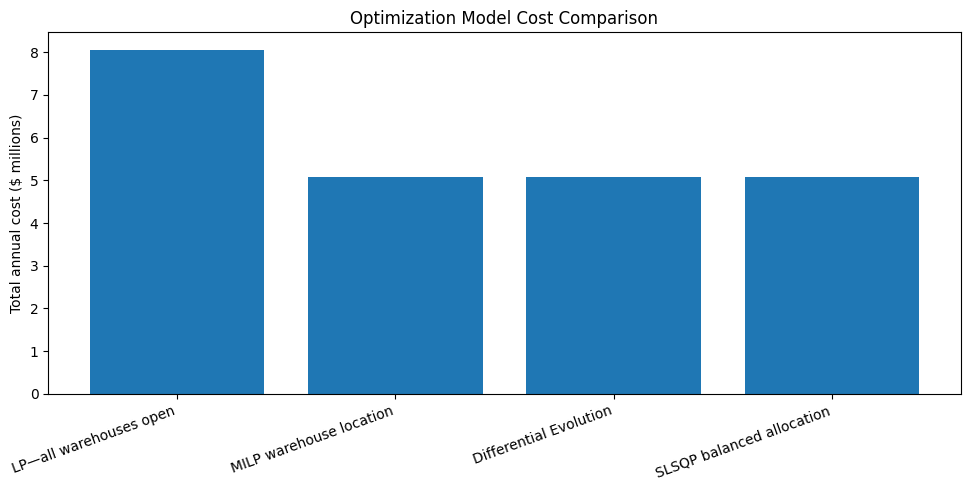

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(comparison_df["Model"],comparison_df["Total cost ($M)"])
plt.ylabel("Total annual cost ($ millions)")
plt.title("Optimization Model Cost Comparison")
plt.xticks(rotation=20,ha="right")
plt.tight_layout()
plt.show()

## Step 16 — Warehouse utilization chart

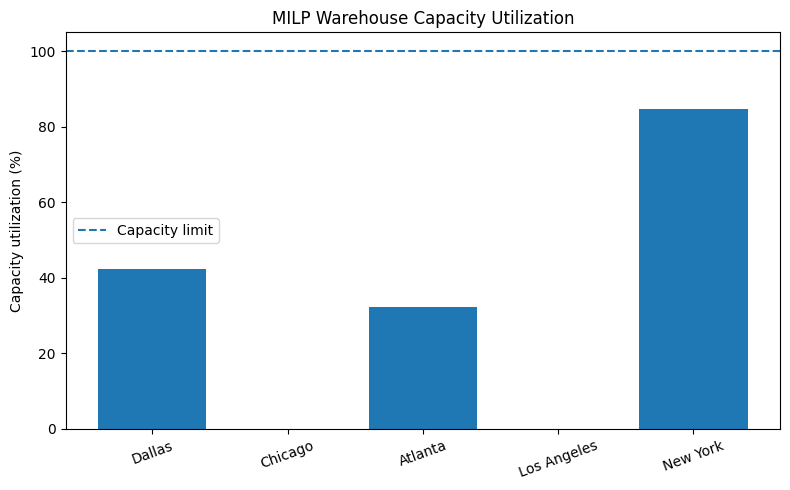

In [ ]:
util = np.where(milp_open==1,milp_allocation.sum(axis=1)/CAPACITY*100,0)
plt.figure(figsize=(8,5))
plt.bar(WAREHOUSES,util)
plt.axhline(100,linestyle="--",label="Capacity limit")
plt.ylabel("Capacity utilization (%)")
plt.title("MILP Warehouse Capacity Utilization")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

## Step 17 — Network diagram

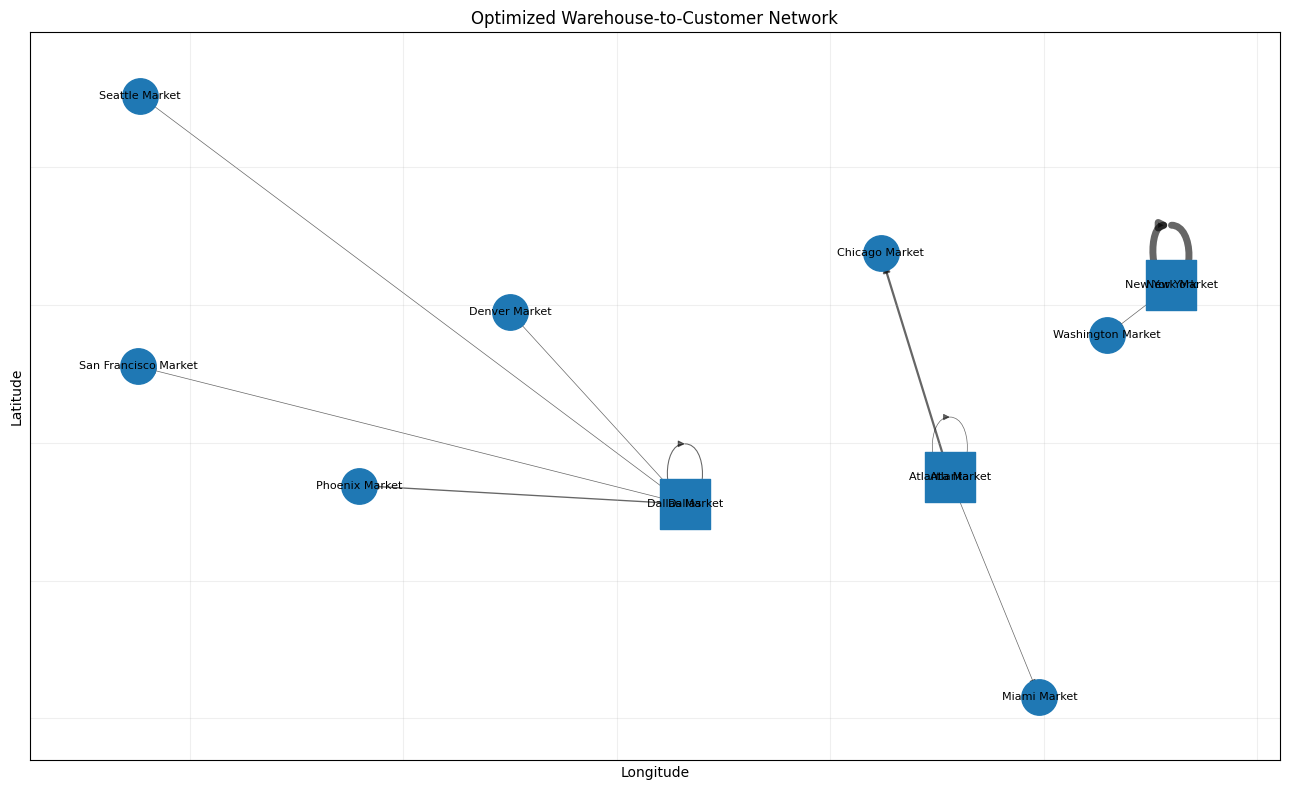

In [ ]:
G = nx.DiGraph()
for i,w in enumerate(WAREHOUSES):
    if milp_open[i]==1:
        G.add_node(w,node_type="warehouse")
for c in CUSTOMERS:
    G.add_node(c+" Market",node_type="customer")
for i,w in enumerate(WAREHOUSES):
    for j,c in enumerate(CUSTOMERS):
        if milp_allocation[i,j] > 1:
            G.add_edge(w,c+" Market",weight=milp_allocation[i,j])

pos = {}
for i,w in enumerate(WAREHOUSES):
    if milp_open[i]==1:
        pos[w]=(COORDINATES[w][1],COORDINATES[w][0])
for c in CUSTOMERS:
    pos[c+" Market"]=(COORDINATES[c][1],COORDINATES[c][0])

w_nodes=[n for n,d in G.nodes(data=True) if d["node_type"]=="warehouse"]
c_nodes=[n for n,d in G.nodes(data=True) if d["node_type"]=="customer"]
widths=[max(0.5,G[u][v]["weight"]/DEMAND.max()*5) for u,v in G.edges()]

plt.figure(figsize=(13,8))
nx.draw_networkx_nodes(G,pos,nodelist=w_nodes,node_shape="s",node_size=1300)
nx.draw_networkx_nodes(G,pos,nodelist=c_nodes,node_shape="o",node_size=650)
nx.draw_networkx_edges(G,pos,width=widths,arrows=True,alpha=0.6)
nx.draw_networkx_labels(G,pos,font_size=8)
plt.title("Optimized Warehouse-to-Customer Network")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(alpha=0.2)
plt.tight_layout(); plt.show()

## Step 18 — Sensitivity analysis

In [ ]:
DEMAND_FACTORS=[0.90,1.00,1.10,1.20]
COST_FACTORS=[0.85,1.00,1.15,1.30]
records=[]

for dfactor in DEMAND_FACTORS:
    for cfactor in COST_FACTORS:
        a,o,total,stime,msg = solve_milp(demand=DEMAND*dfactor,cost_matrix=TRANSPORT_COST*cfactor)
        records.append({
            "Demand factor":dfactor,
            "Cost factor":cfactor,
            "Demand change":f"{dfactor-1:+.0%}",
            "Transport-cost change":f"{cfactor-1:+.0%}",
            "Total cost ($M)":np.nan if a is None else total/1e6,
            "Warehouses open":np.nan if o is None else int(o.sum()),
            "Selected warehouses":"Infeasible" if o is None else ", ".join(np.array(WAREHOUSES)[o==1]),
            "Solve time seconds":stime
        })

sensitivity_df=pd.DataFrame(records)
sensitivity_df.round(4)

,Demand factor,Cost factor,Demand change,Transport-cost change,Total cost ($M),Warehouses open,Selected warehouses,Solve time seconds
0,0.9,0.85,-10%,-15%,4.9204,3,"Dallas, Chicago, Atlanta",0.0184
1,0.9,1.00,-10%,+0%,5.0285,3,"Dallas, Atlanta, New York",0.0141
2,0.9,1.15,-10%,+15%,5.1078,3,"Dallas, Atlanta, New York",0.0263
3,0.9,1.30,-10%,+30%,5.1871,3,"Dallas, Atlanta, New York",0.0146
4,1.0,0.85,+0%,-15%,4.9992,3,"Dallas, Atlanta, New York",0.0158
5,1.0,1.00,+0%,+0%,5.0873,3,"Dallas, Atlanta, New York",0.0267
6,1.0,1.15,+0%,+15%,5.1754,3,"Dallas, Atlanta, New York",0.0358
7,1.0,1.30,+0%,+30%,5.2634,3,"Dallas, Atlanta, New York",0.0145
8,1.1,0.85,+10%,-15%,5.0491,3,"Dallas, Atlanta, New York",0.0146
9,1.1,1.00,+10%,+0%,5.1460,3,"Dallas, Atlanta, New York",0.0144


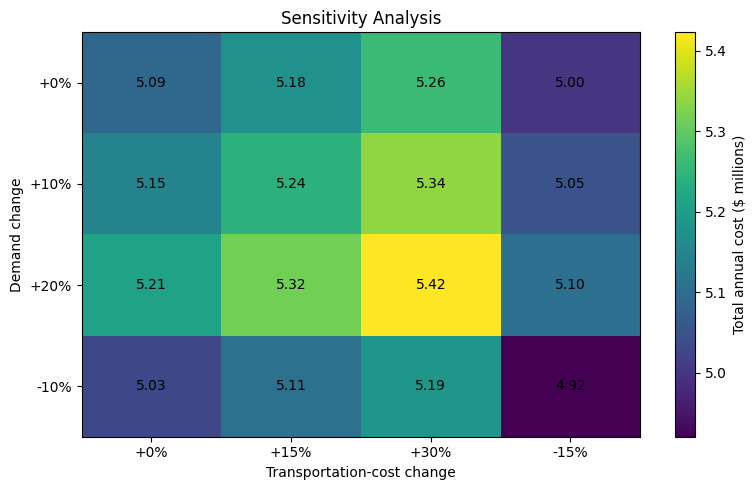

In [ ]:
heatmap=sensitivity_df.pivot(index="Demand change",columns="Transport-cost change",values="Total cost ($M)")
plt.figure(figsize=(8,5))
img=plt.imshow(heatmap.values,aspect="auto")
plt.colorbar(img,label="Total annual cost ($ millions)")
plt.xticks(range(len(heatmap.columns)),heatmap.columns)
plt.yticks(range(len(heatmap.index)),heatmap.index)
plt.xlabel("Transportation-cost change"); plt.ylabel("Demand change")
plt.title("Sensitivity Analysis")
for r in range(heatmap.shape[0]):
    for c in range(heatmap.shape[1]):
        v=heatmap.iloc[r,c]
        if pd.notna(v): plt.text(c,r,f"{v:.2f}",ha="center",va="center")
plt.tight_layout(); plt.show()

## Step 19 — Business summary

In [ ]:
selected=[WAREHOUSES[i] for i in range(M) if milp_open[i]==1]
savings=lp_total_cost-milp_total_cost
weighted_time=np.sum(milp_allocation*DELIVERY_TIME)/milp_allocation.sum()
max_time=DELIVERY_TIME[milp_allocation>1e-4].max()

summary_df=pd.DataFrame({
    "Metric":["Total annual demand","Optimal warehouses","MILP total cost","All-open LP benchmark","Annual savings","Savings %","Average delivery time","Maximum used route time"],
    "Result":[f"{DEMAND.sum():,.0f} units",", ".join(selected),f"${milp_total_cost:,.2f}",f"${lp_total_cost:,.2f}",
              f"${savings:,.2f}",f"{savings/lp_total_cost*100:.2f}%",f"{weighted_time:.2f} hours",f"{max_time:.2f} hours"]
})
summary_df

,Metric,Result
0,Total annual demand,"905,000 units"
1,Optimal warehouses,"Dallas, Atlanta, New York"
2,MILP total cost,"$5,087,263.37"
3,All-open LP benchmark,"$8,060,979.18"
4,Annual savings,"$2,973,715.81"
5,Savings %,36.89%
6,Average delivery time,10.19 hours
7,Maximum used route time,39.47 hours
